In [86]:
import os
import sys

sys.path.append(os.path.join(os.path.dirname(__vsc_ipynb_file__), ".."))

import numpy as np
import numba
import matplotlib.pyplot as plt

from params import RestrepoParams
from cpu import *
from utils import luminal_buffer
#from sde import mean_reverting_gbm, levy_ou_process
import sympy

In [120]:
params = RestrepoParams(Ku=1.4e-4, h=2.5)

In [164]:
def beta_s(cs, params):
    calmodulin_buf = params.BCAM * params.KCAM / (cs + params.KCAM)**2
    SLH_buf = params.BSLH * params.KSLH / (cs + params.KSLH)**2
    return 1 / (1 + calmodulin_buf + SLH_buf)

def beta_s_small_c_approx(cs, params):
    t1 = params.BSLH / (8*params.KSLH**2) + params.BCAM * params.KCAM / (params.KSLH + params.KCAM)**3
    t2 = params.BSLH / (16*params.KSLH**3) + params.BCAM * params.KCAM / (params.KSLH + params.KCAM)**4
    a0 = beta_s(params.KSLH, params)
    a1 = 2 * t1 * a0**2
    #a2 = 4*t1*a0*a1 - 6*t2*a0**2
    return a0 + a1*(cs - params.KSLH) #+ 0.5*a2*(cs - params.KSLH)**2

def beta_s_big_c_approx(cs, params):
    t1 = params.BCAM / (8*params.KCAM**2) + params.BSLH * params.KSLH / (params.KSLH + params.KCAM)**3
    t2 = params.BCAM / (16*params.KCAM**3) + params.BSLH * params.KSLH / (params.KSLH + params.KCAM)**4
    t3 = params.BCAM / (32*params.KCAM**4) + params.BSLH * params.KSLH / (params.KSLH + params.KCAM)**5
    a0 = beta_s(params.KCAM, params)
    a1 = 2 * t1 * a0**2
    a2 = 4*t1*a0*a1 - 6*t2*a0**2
    a3 = 24 * (t3*a0**2 - t2*a0*a1) + 4 * t1 * (a2*a0 + a1**2)
    return a0 + a1*(cs - params.KCAM) + 0.5*a2*(cs - params.KCAM)**2 + (1/6)*a3*(cs-params.KCAM)**3


def beta_j(cj, params):
    out = np.zeros_like(cj)
    for i, c in enumerate(cj):
        out[i] = luminal_buffer(c, params)
    return out

In [165]:
cs_range = np.linspace(0.0, 30.0, num=10000)
cj_range = np.linspace(200.0, 1400.0, num=10000)

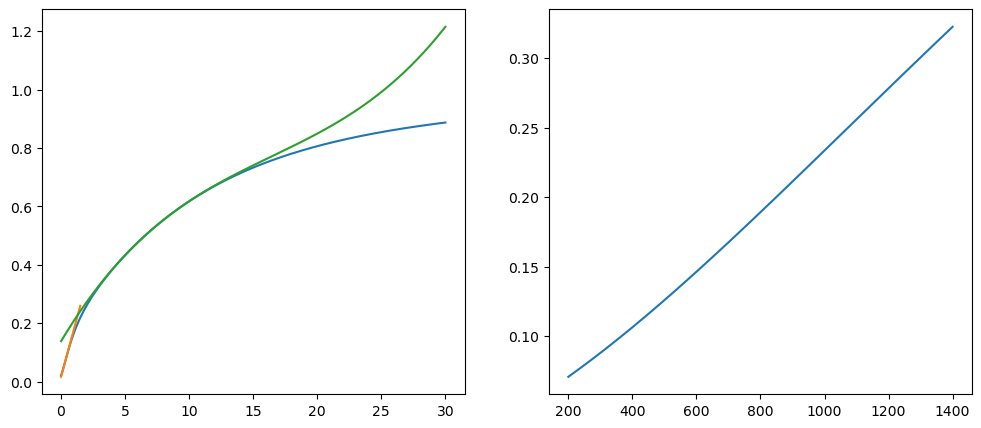

In [166]:
fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(cs_range, beta_s(cs_range, params))
ax[0].plot(cs_range[:500], beta_s_small_c_approx(cs_range[:500], params))
ax[0].plot(cs_range, beta_s_big_c_approx(cs_range, params))
ax[1].plot(cj_range, beta_j(cj_range, params))
plt.show()

In [276]:
Po = sympy.symbols('P_o', Real=True)
cp, cj, cs, cn, ci, R1, CaTs = sympy.symbols('c_p c_j c_s c_n c_i R_1 CaT_s', Real=True)
Ku = sympy.symbols('K_u', Real=True)
Kb = sympy.symbols('K_b', Real=True)
kr = sympy.symbols('k_r', Real=True)
tau_p = sympy.symbols('tau_p', Real=True)
tau_s = sympy.symbols('tau_s', Real=True)
vp = sympy.symbols('v_p', Real=True)
vj = sympy.symbols('v_j', Real=True)
vs = sympy.symbols('v_s', Real=True)
kon = sympy.symbols('k_1', Real=True)
koff = sympy.symbols('k_2', Real=True)
B = sympy.symbols('B', Real=True)


In [277]:
cp_ = (cs + kr * Po * cj) / (1 + kr *Po)

In [279]:
dcp_dPo = sympy.diff(cp_, Po).cancel().factor()
dcp2_dPo2 = sympy.diff(dcp_dPo, Po).cancel().factor()

In [280]:
dcp_dPo

k_r*(c_j - c_s)/(P_o*k_r + 1)**2

In [281]:
dcp2_dPo2

-2*k_r**2*(c_j - c_s)/(P_o*k_r + 1)**3

In [282]:
eps2 = sympy.nsimplify(0.1**2)

cp2 = cp**2
Po_subs = (cs - cp) / (kr*(cp - cj))
dcp_dPo_subs = dcp_dPo.subs({Po: Po_subs}).simplify()
dcp2_dPo2_subs = dcp2_dPo2.subs({Po: Po_subs}).simplify()
R4 = (1 - (R1 + Po_subs)).simplify()

In [283]:
dcp_dPo_subs

k_r*(c_j - c_p)**2/(c_j - c_s)

In [284]:
dcp2_dPo2_subs

-2*k_r**2*(c_j - c_p)**3/(c_j - c_s)**2

Create placeholders for $c_j - c_p$ and $c_j - c_s$ to help with simplification later

In [320]:
djp, djs, dsp, dnj, dsi = sympy.symbols('d_{jp} d_{js} d_{sp} d_{nj} d_{si}')

Po_ph = -dsp / (kr*djp)
dcp_dPo_ph = kr * djp**2 / djs
dcp2_dPo2_ph = -2*(kr**2) * djp**3 / djs**2
R4_ph = (1 - (R1 + Po_ph)).simplify()

In [314]:
Itr = dnj / 5 # using tau_tr = 5
Ir = ((kr / tau_p) * Po_ph * djs).simplify()
drift_cj = (Itr - (vp / vj) * Ir).simplify() # No beta term here
#dcp_dcj = (kr * Po_ph / (1 + kr * Po_ph)).simplify()
dcp_dcj = -dsp / djs

In [315]:
Idps = -dsp / tau_p
Idsi = dsi / tau_s
ITcs = kon*cs*(B-CaTs) - koff*CaTs
drift_cs = ((vp/vs) * Idps - Idsi - ITcs).simplify() # No beta term here
#dcp_dcs = (1 / (1 + kr * Po_ph)).simplify()
dcp_dcs = djp / djs

In [322]:
drift_Po = ((Ku*R1 + Kb*R4_ph)*cp2 - Po_ph).simplify() # using tau_c = 1
tr_hess_term = ((eps2 / 2) * dcp2_dPo2_ph * ((Ku*R1 + Kb*R4_ph)*cp2 + Po_ph)).simplify() # using tau_c = 1

In [324]:
drift_cp = sympy.simplify((
    dcp_dPo_ph * drift_Po +
    dcp_dcj * drift_cj +
    dcp_dcs * drift_cs +
    tr_hess_term)
    )

In [325]:
drift_cp

(d_{jp}**3*k_r*tau_p*tau_s*v_j*v_s*(c_p**2*(K_b*(d_{jp}*k_r*(R_1 - 1) - d_{sp}) - K_u*R_1*d_{jp}*k_r) + d_{sp})/100 + d_{jp}**2*d_{js}*tau_p*tau_s*v_j*v_s*(c_p**2*(-K_b*(d_{jp}*k_r*(R_1 - 1) - d_{sp}) + K_u*R_1*d_{jp}*k_r) + d_{sp}) - d_{jp}**2*d_{js}*v_j*(d_{si}*tau_p*v_s + d_{sp}*tau_s*v_p + tau_p*tau_s*v_s*(B*c_s*k_1 - CaT_s*c_s*k_1 - CaT_s*k_2)) - d_{js}*d_{sp}*tau_s*v_s*(d_{jp}*d_{nj}*tau_p*v_j + 5*d_{js}*d_{sp}*v_p)/5)/(d_{jp}*d_{js}**2*tau_p*tau_s*v_j*v_s)

In [328]:
# The sum of the square diffusion terms (i.e. the variance of the increments)
diff2_cp = (eps2 * (dcp_dPo_ph ** 2) * ((Ku*R1 + Kb*R4_ph)*cp2 + Po_ph)).simplify() # using tau_c = 1

In [329]:
diff2_cp

d_{jp}**3*k_r*(c_p**2*(K_b*(d_{jp}*k_r*(1 - R_1) + d_{sp}) + K_u*R_1*d_{jp}*k_r) - d_{sp})/(100*d_{js}**2)

In [330]:
params.Jmax * params.tau_ps / params.vp

0.25666666

In [331]:
drift_cp_subs = drift_cp.subs({Ku: 1.4e-4, Kb: 5e-5, tau_p: 0.022, tau_s: 0.1, vp: 0.00126, vs: 0.025, vj: 0.02, kon: 0.0327, koff: 0.0196, B: 70, kr: 0.2567})

In [332]:
num, denom = drift_cp_subs.as_numer_denom()

In [333]:
num

0.002567*d_{jp}**3*(c_p**2*(-3.5938e-5*R_1*d_{jp} + 1.2835e-5*d_{jp}*(R_1 - 1) - 5.0e-5*d_{sp}) + d_{sp}) + 1.0*d_{jp}**2*d_{js}*(c_p**2*(3.5938e-5*R_1*d_{jp} - 1.2835e-5*d_{jp}*(R_1 - 1) + 5.0e-5*d_{sp}) + d_{sp}) - 18181.8181818182*d_{jp}**2*d_{js}*(-1.7985e-6*CaT_s*c_s - 1.078e-6*CaT_s + 0.000125895*c_s + 0.00055*d_{si} + 0.000126*d_{sp}) - 454.545454545455*d_{js}*d_{sp}*(0.00044*d_{jp}*d_{nj} + 0.0063*d_{js}*d_{sp})

In [334]:
denom

d_{jp}*d_{js}**2

In [371]:
t1, rem1 = sympy.reduced(num, [djp*djs**2])
t1[0].simplify().factor()

0

In [372]:
rem1

0.0327*CaT_s*c_s*d_{jp}**2*d_{js} + 0.0196*CaT_s*d_{jp}**2*d_{js} - 5.9305401e-8*R_1*c_p**2*d_{jp}**4 + 2.3103e-5*R_1*c_p**2*d_{jp}**3*d_{js} - 3.2947445e-8*c_p**2*d_{jp}**4 + 1.2835e-5*c_p**2*d_{jp}**3*d_{js} - 1.2835e-7*c_p**2*d_{jp}**3*d_{sp} + 5.0e-5*c_p**2*d_{jp}**2*d_{js}*d_{sp} - 2.289*c_s*d_{jp}**2*d_{js} + 0.002567*d_{jp}**3*d_{sp} - 10.0*d_{jp}**2*d_{js}*d_{si} - 1.29090909090909*d_{jp}**2*d_{js}*d_{sp} - 0.2*d_{jp}*d_{js}*d_{nj}*d_{sp} - 2.86363636363636*d_{js}**2*d_{sp}**2

In [373]:
t2, rem2 = sympy.reduced(rem1, [djp*djs])
t2[0].factor()

10.0*(0.00327*CaT_s*c_s*d_{jp} + 0.00196*CaT_s*d_{jp} + 2.3103e-6*R_1*c_p**2*d_{jp}**2 + 1.2835e-6*c_p**2*d_{jp}**2 + 5.0e-6*c_p**2*d_{jp}*d_{sp} - 0.2289*c_s*d_{jp} - 1.0*d_{jp}*d_{si} - 0.129090909090909*d_{jp}*d_{sp} - 0.02*d_{nj}*d_{sp})

In [375]:
rem2

-5.9305401e-8*R_1*c_p**2*d_{jp}**4 - 3.2947445e-8*c_p**2*d_{jp}**4 - 1.2835e-7*c_p**2*d_{jp}**3*d_{sp} + 0.002567*d_{jp}**3*d_{sp} - 2.86363636363636*d_{js}**2*d_{sp}**2

In [374]:
t3, rem3 = sympy.reduced(rem2, [djp])
t3[0].factor()

-0.002567*d_{jp}**2*(2.3103e-5*R_1*c_p**2*d_{jp} + 1.2835e-5*c_p**2*d_{jp} + 5.0e-5*c_p**2*d_{sp} - 1.0*d_{sp})

In [376]:
rem3

-2.86363636363636*d_{js}**2*d_{sp}**2

In [381]:
diff2_subs = diff2_cp.subs({Ku: 1.4e-4, Kb: 5e-5, tau_p: 0.022, tau_s: 0.1, vp: 0.00126, vs: 0.025, vj: 0.02, kon: 0.0327, koff: 0.0196, B: 70, kr: 0.2567})

In [392]:
diff2_subs = diff2_subs.subs({djp: cj-cp, djs: cj-cs, dsp: cs-cp}).expand()

In [393]:
sympy.poly(diff2_subs, cp)

Poly((5.9305401e-8*R_1 + 1.61297445e-7)/(1.0*c_j**2 - 2.0*c_j*c_s + 1.0*c_s**2)*c_p**6 + (-2.37221604e-7*R_1*c_j - 5.1683978e-7*c_j - 1.2835e-7*c_s)/(1.0*c_j**2 - 2.0*c_j*c_s + 1.0*c_s**2)*c_p**5 + (3.55832406e-7*R_1*c_j**2 + 5.8273467e-7*c_j**2 + 3.8505e-7*c_j*c_s - 0.002567)/(1.0*c_j**2 - 2.0*c_j*c_s + 1.0*c_s**2)*c_p**4 + (-2.37221604e-7*R_1*c_j**3 - 2.6013978e-7*c_j**3 - 3.8505e-7*c_j**2*c_s + 0.007701*c_j + 0.002567*c_s)/(1.0*c_j**2 - 2.0*c_j*c_s + 1.0*c_s**2)*c_p**3 + (5.9305401e-8*R_1*c_j**4 + 3.2947445e-8*c_j**4 + 1.2835e-7*c_j**3*c_s - 0.007701*c_j**2 - 0.007701*c_j*c_s)/(1.0*c_j**2 - 2.0*c_j*c_s + 1.0*c_s**2)*c_p**2 + (0.002567*c_j**3 + 0.007701*c_j**2*c_s)/(1.0*c_j**2 - 2.0*c_j*c_s + 1.0*c_s**2)*c_p - 0.002567*c_j**3*c_s/(1.0*c_j**2 - 2.0*c_j*c_s + 1.0*c_s**2), c_p, domain='RR(R_1,c_j,c_s)')